# Customer Churn Prediction
### Machine Learning Project


In [180]:
import pandas as pd

In [181]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [182]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [183]:
df.shape

(7043, 21)

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [185]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [186]:
df['TotalCharges'].dtype

dtype('O')

In [187]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [188]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [189]:
df = df.dropna(subset=['TotalCharges'])

In [190]:
df.duplicated().sum()

np.int64(0)

In [191]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [192]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [193]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [195]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


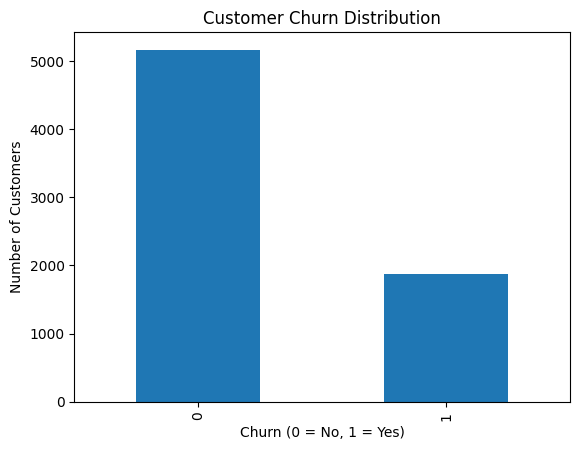

In [196]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

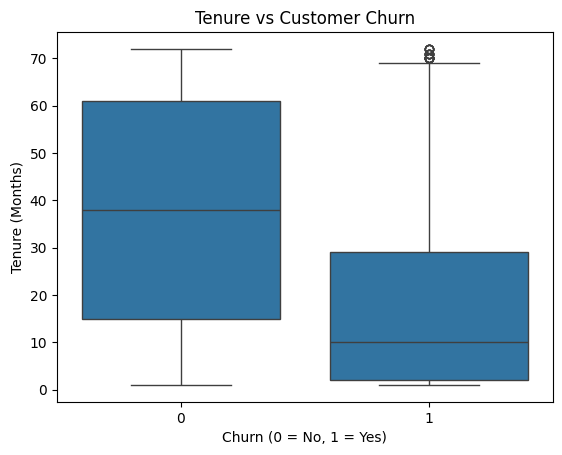

In [197]:
import seaborn as sns

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Tenure vs Customer Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (Months)')
plt.show()

In [198]:
df.groupby('Contract')['Churn'].mean() * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


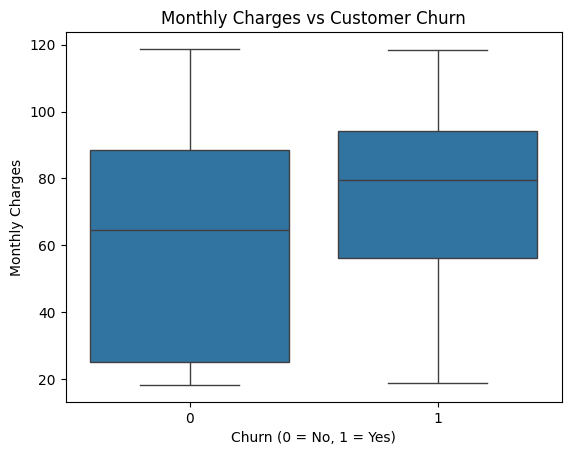

In [199]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')
plt.show()

In [200]:
df.groupby('InternetService')['Churn'].mean() * 100

,Churn
InternetService,
DSL,18.998344
Fiber optic,41.892765
No,7.434211


In [201]:
df.groupby('Contract')['Churn'].mean() * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


In [202]:
df.groupby('PaymentMethod')['Churn'].mean() * 100

,Churn
PaymentMethod,
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123
Electronic check,45.285412
Mailed check,19.201995


In [203]:
df.groupby('TechSupport')['Churn'].mean() * 100

,Churn
TechSupport,
No,41.647465
No internet service,7.434211
Yes,15.196078


In [204]:
df.groupby('OnlineSecurity')['Churn'].mean() * 100

,Churn
OnlineSecurity,
No,41.778667
No internet service,7.434211
Yes,14.640199


In [205]:
df.groupby('PaperlessBilling')['Churn'].mean() * 100

,Churn
PaperlessBilling,
No,16.375698
Yes,33.589251


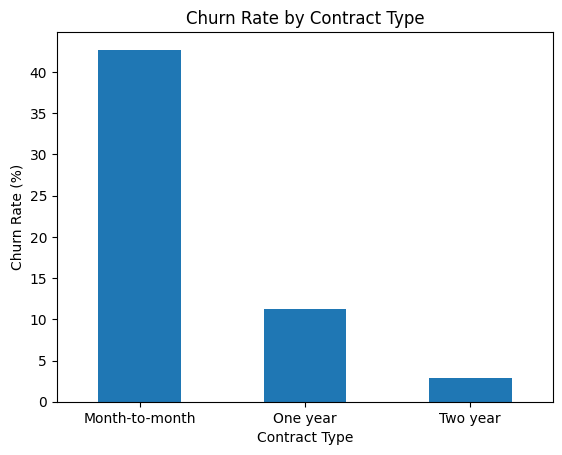

In [206]:
contract_churn = df.groupby('Contract')['Churn'].mean() * 100

contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [207]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [208]:
X = X.drop('customerID', axis=1)

In [209]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [210]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [212]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [213]:
y_pred = model.predict(X_test)

print("Predictions made successfully!")
print(y_pred[:20])

Predictions made successfully!
[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0]


In [214]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.7874911158493249
Accuracy Percentage: 78.74911158493248 %


Confusion Matrix:
[[915 118]
 [181 193]]


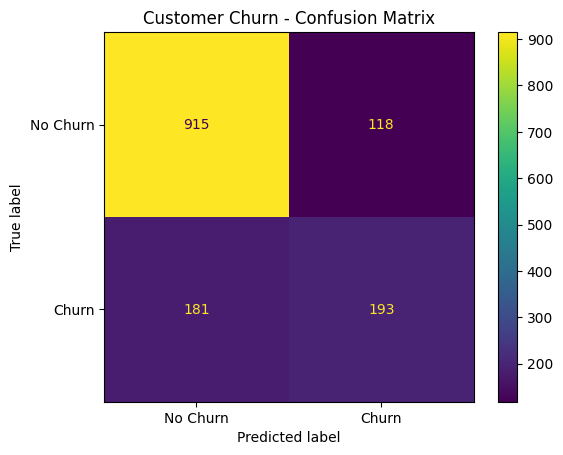

In [215]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Customer Churn - Confusion Matrix")
plt.show()

In [216]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [217]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed successfully!")

Data scaling completed successfully!


In [218]:
model_scaled = LogisticRegression(max_iter=2000)

model_scaled.fit(X_train_scaled, y_train)

print("Improved model trained successfully!")

Improved model trained successfully!


In [219]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Improved predictions made successfully!")
print(y_pred_scaled[:20])

Improved predictions made successfully!
[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0]


In [220]:
from sklearn.metrics import accuracy_score

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Improved Model Accuracy:", accuracy_scaled)
print("Improved Accuracy Percentage:", accuracy_scaled * 100, "%")

Improved Model Accuracy: 0.7874911158493249
Improved Accuracy Percentage: 78.74911158493248 %


In [221]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_scaled))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



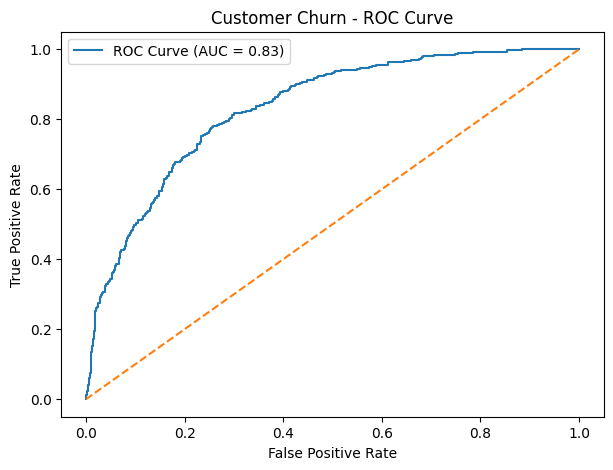

ROC-AUC Score: 0.8319235288940887


In [222]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


y_prob = model_scaled.predict_proba(X_test_scaled)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob)


auc_score = roc_auc_score(y_test, y_prob)


plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Customer Churn - ROC Curve')
plt.legend()
plt.show()

print("ROC-AUC Score:", auc_score)

In [223]:


feature_names = X_train.columns

coefficients = model_scaled.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['Importance'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                        Feature  Coefficient  Importance
1                        tenure    -1.445747    1.445747
3                  TotalCharges     0.694885    0.694885
10  InternetService_Fiber optic     0.650749    0.650749
2                MonthlyCharges    -0.632801    0.632801
25            Contract_Two year    -0.567396    0.567396
24            Contract_One year    -0.314562    0.314562
23          StreamingMovies_Yes     0.222440    0.222440
21              StreamingTV_Yes     0.212963    0.212963
9             MultipleLines_Yes     0.160546    0.160546
13           OnlineSecurity_Yes    -0.155520    0.155520


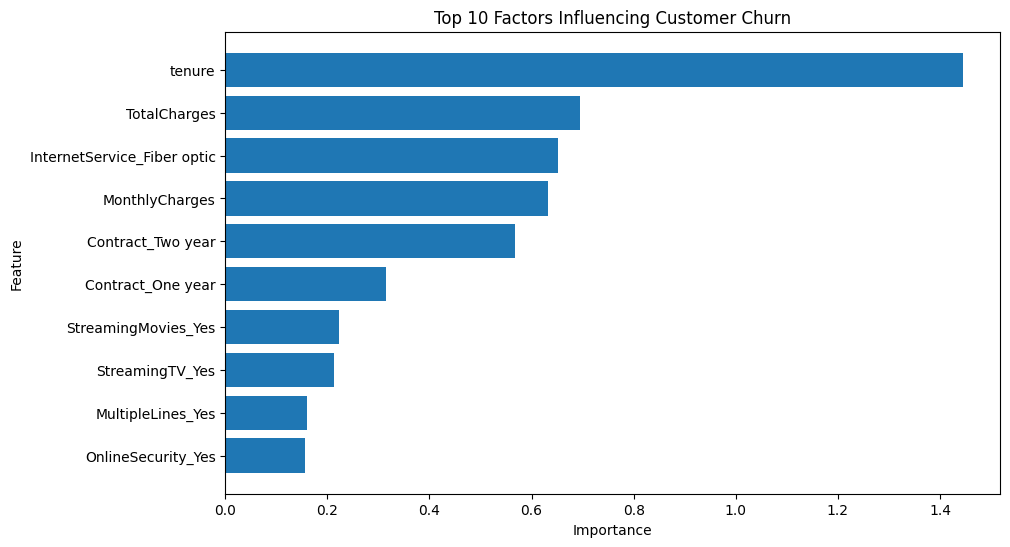

In [224]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Factors Influencing Customer Churn')

plt.gca().invert_yaxis()

plt.show()

In [225]:


feature_importance['Effect'] = feature_importance['Coefficient'].apply(
    lambda x: 'Increases Churn' if x > 0 else 'Decreases Churn'
)

print(feature_importance.head(10))

                        Feature  Coefficient  Importance           Effect
1                        tenure    -1.445747    1.445747  Decreases Churn
3                  TotalCharges     0.694885    0.694885  Increases Churn
10  InternetService_Fiber optic     0.650749    0.650749  Increases Churn
2                MonthlyCharges    -0.632801    0.632801  Decreases Churn
25            Contract_Two year    -0.567396    0.567396  Decreases Churn
24            Contract_One year    -0.314562    0.314562  Decreases Churn
23          StreamingMovies_Yes     0.222440    0.222440  Increases Churn
21              StreamingTV_Yes     0.212963    0.212963  Increases Churn
9             MultipleLines_Yes     0.160546    0.160546  Increases Churn
13           OnlineSecurity_Yes    -0.155520    0.155520  Decreases Churn


In [226]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_scaled)
precision = precision_score(y_test, y_pred_scaled)
recall = recall_score(y_test, y_pred_scaled)
f1 = f1_score(y_test, y_pred_scaled)

print("Customer Churn Prediction - Model Performance")
print("-----------------------------------------------")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1-Score :", round(f1 * 100, 2), "%")
print("ROC-AUC  :", round(auc_score, 2))

Customer Churn Prediction - Model Performance
-----------------------------------------------
Accuracy : 78.75 %
Precision: 62.06 %
Recall   : 51.6 %
F1-Score : 56.35 %
ROC-AUC  : 0.83


In [227]:
import pandas as pd

df = pd.read_csv('/content/Telco-Customer-Churn.csv')

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(7043, 21)


In [228]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X = X.drop('customerID', axis=1)

print("X and y created successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

X and y created successfully!
X shape: (7043, 19)
y shape: (7043,)


In [229]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [230]:


X = df.drop('Churn', axis=1)


X = X.drop('customerID', axis=1, errors='ignore')

X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')


X['TotalCharges'] = X['TotalCharges'].fillna(X['TotalCharges'].median())


X = pd.get_dummies(X, drop_first=True)


y = df['Churn'].map({'No': 0, 'Yes': 1})

print("Data preprocessing completed!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Data preprocessing completed!
X shape: (7043, 30)
y shape: (7043,)


In [231]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [232]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [233]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score


y_pred_rf = rf_model.predict(X_test)


y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Model Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy_rf * 100, 2), "%")
print("Recall   :", round(recall_rf * 100, 2), "%")
print("ROC-AUC  :", round(auc_rf, 2))

Random Forest Model Performance
--------------------------------
Accuracy : 78.92 %
Recall   : 45.84 %
ROC-AUC  : 0.84


Random Forest Confusion Matrix:
[[941  95]
 [202 171]]


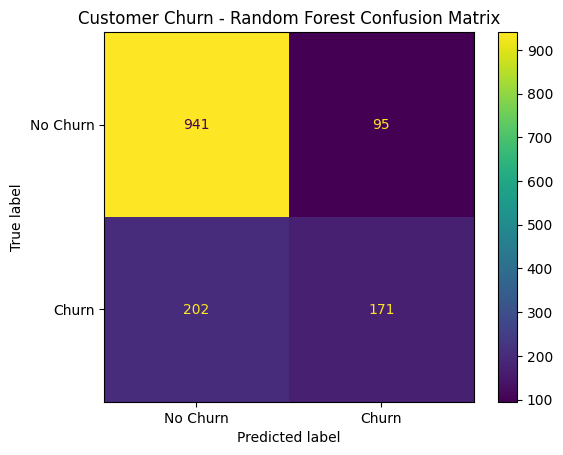

In [234]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Customer Churn - Random Forest Confusion Matrix")
plt.show()

Random Forest ROC-AUC: 0.84


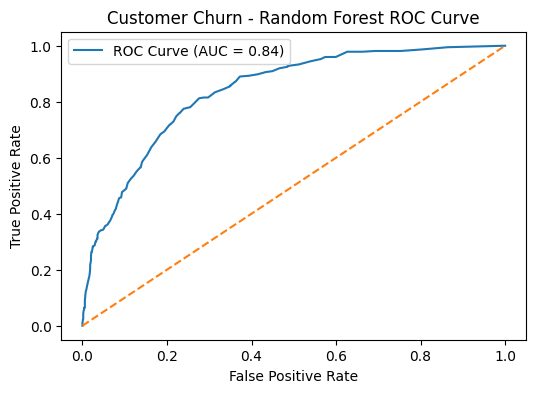

In [235]:
from sklearn.metrics import roc_curve, roc_auc_score


fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)


auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", round(auc_rf, 2))


plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_rf:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Customer Churn - Random Forest ROC Curve")
plt.legend()
plt.show()

In [236]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)


y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf * 100, 2), "%")
print("Recall   :", round(recall_rf * 100, 2), "%")
print("ROC-AUC  :", round(auc_rf, 2))

Random Forest Results
---------------------
Accuracy : 78.92 %
Recall   : 45.84 %
ROC-AUC  : 0.84


In [237]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [238]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions completed!")

XGBoost predictions completed!


In [239]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(accuracy_xgb * 100, 2), "%")
print("Recall   :", round(recall_xgb * 100, 2), "%")
print("ROC-AUC  :", round(auc_xgb, 2))

XGBoost Results
----------------
Accuracy : 79.42 %
Recall   : 52.28 %
ROC-AUC  : 0.84


In [240]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [78.75, 78.92, 79.42],
    'Recall': [51.60, 45.84, 52.28],
    'ROC-AUC': [0.83, 0.84, 0.84]
})

comparison

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,78.75,51.60,0.83
1,Random Forest,78.92,45.84,0.84
2,XGBoost,79.42,52.28,0.84
